In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GOOGLE_API_KEY"]=os.getenv("GOOGLE_API_KEY")

In [3]:
# print(os.getenv("GOOGLE_API_KEY"))

In [4]:
from langchain_google_genai import ChatGoogleGenerativeAI

model=ChatGoogleGenerativeAI(model="gemini-flash-latest", google_api_key=os.getenv("GOOGLE_API_KEY"))
output=model.invoke("hi")
output.content


[{'type': 'text',
  'text': 'Hello! How can I help you today?',
  'extras': {'signature': 'EqoCCqcCAQw51seKy2GSpKkSwBh23uT1b8XwokI76lgeJ/KsXja41uevwN8b3X7aeIJ8LorEQQtQnP38x8oR0O7I6xsw+pZpmvO0WSdifw9NyOyqg7X5F0TcFocWjNJquGARNxvZXtc6NoLfzv2tSBDk8R8JmDptCD30DmyJbyX/YG+jg7UdAemUrO/tNCwvBNfqy1h4bCWP5nyXmADVfp1VYgkeXqm23wa/qzztxwExrCfq+ecQpQb6RkdBxei483IF7AVCtKvVD4yCzkX9OKV5ynm7AisVuVcek1f/twpoawoFIsvcIntL306qWecf1KAoM1HiGqG/ElfjlsiB3gYnHq0hfnGRoRGzyvWH30M2rJEybOOkKoSLbD6SjscflJ8ddywoi96vULqI2g=='}}]

#### Configure the Embedding Model

In [5]:
from langchain_huggingface import HuggingFaceEmbeddings
embeddings=HuggingFaceEmbeddings(model_name="BAAI/bge-small-en")
len(embeddings.embed_query("Hello, world!"))

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/684 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

384

#### Embedding & Storing the data in the Vector DB

In [6]:
from langchain_community.document_loaders import TextLoader, DirectoryLoader
from langchain_community.vectorstores import Chroma
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [7]:

loader=DirectoryLoader("../data2",glob="*.txt",loader_cls=TextLoader)

# DirectoryLoader("../data2",glob="*.txt",loader_cls=TextLoader)

In [8]:
docs=loader.load()

In [9]:
docs

[Document(metadata={'source': '../data2/usa.txt'}, page_content="🇺🇸 Overview of the U.S. Economy\nThe United States of America possesses the largest economy in the world in terms of nominal GDP, making it the most powerful economic force globally. It operates under a capitalist mixed economy, where the private sector dominates, but the government plays a significant regulatory and fiscal role. With a population of over 335 million people and a high level of technological advancement, the U.S. economy thrives on a foundation of consumer spending, innovation, global trade, and financial services. It has a highly diversified structure with strong sectors in technology, healthcare, finance, real estate, defense, and agriculture.\n\nU.S. GDP – Size, Composition, and Global Share\nAs of 2024, the United States’ nominal GDP is estimated to be around $28 trillion USD, accounting for approximately 25% of the global economy. It ranks #1 in the world by nominal GDP, far ahead of China (which rank

In [10]:
docs[0].page_content

"🇺🇸 Overview of the U.S. Economy\nThe United States of America possesses the largest economy in the world in terms of nominal GDP, making it the most powerful economic force globally. It operates under a capitalist mixed economy, where the private sector dominates, but the government plays a significant regulatory and fiscal role. With a population of over 335 million people and a high level of technological advancement, the U.S. economy thrives on a foundation of consumer spending, innovation, global trade, and financial services. It has a highly diversified structure with strong sectors in technology, healthcare, finance, real estate, defense, and agriculture.\n\nU.S. GDP – Size, Composition, and Global Share\nAs of 2024, the United States’ nominal GDP is estimated to be around $28 trillion USD, accounting for approximately 25% of the global economy. It ranks #1 in the world by nominal GDP, far ahead of China (which ranks 2nd). The U.S. GDP per capita is also among the highest, hover

In [11]:
text_splitter=RecursiveCharacterTextSplitter(chunk_size=200, chunk_overlap=50)

In [12]:
new_docs=text_splitter.split_documents(docs)
new_docs


[Document(metadata={'source': '../data2/usa.txt'}, page_content='🇺🇸 Overview of the U.S. Economy'),
 Document(metadata={'source': '../data2/usa.txt'}, page_content='The United States of America possesses the largest economy in the world in terms of nominal GDP, making it the most powerful economic force globally. It operates under a capitalist mixed economy,'),
 Document(metadata={'source': '../data2/usa.txt'}, page_content='It operates under a capitalist mixed economy, where the private sector dominates, but the government plays a significant regulatory and fiscal role. With a population of over 335 million people and a'),
 Document(metadata={'source': '../data2/usa.txt'}, page_content='a population of over 335 million people and a high level of technological advancement, the U.S. economy thrives on a foundation of consumer spending, innovation, global trade, and financial services.'),
 Document(metadata={'source': '../data2/usa.txt'}, page_content='innovation, global trade, and finan

In [13]:
doc_string=[doc.page_content for doc in new_docs]

In [14]:
doc_string

['🇺🇸 Overview of the U.S. Economy',
 'The United States of America possesses the largest economy in the world in terms of nominal GDP, making it the most powerful economic force globally. It operates under a capitalist mixed economy,',
 'It operates under a capitalist mixed economy, where the private sector dominates, but the government plays a significant regulatory and fiscal role. With a population of over 335 million people and a',
 'a population of over 335 million people and a high level of technological advancement, the U.S. economy thrives on a foundation of consumer spending, innovation, global trade, and financial services.',
 'innovation, global trade, and financial services. It has a highly diversified structure with strong sectors in technology, healthcare, finance, real estate, defense, and agriculture.',
 'U.S. GDP – Size, Composition, and Global Share',
 'As of 2024, the United States’ nominal GDP is estimated to be around $28 trillion USD, accounting for approximately 

In [15]:
len(doc_string)

55

In [16]:
db=Chroma.from_documents(documents=new_docs, embedding=embeddings)

In [17]:
retriever=db.as_retriever(search_kwargs={"k": 3})

In [18]:
retriever.invoke("Industrial growth of USA?")

[Document(metadata={'source': '../data2/usa.txt'}, page_content='Looking forward, the U.S. economy is expected to grow at a moderate pace, powered by innovation in AI, green energy, robotics, biotech, and quantum computing. The Biden administration’s Inflation'),
 Document(metadata={'source': '../data2/usa.txt'}, page_content='🇺🇸 Overview of the U.S. Economy'),
 Document(metadata={'source': '../data2/usa.txt'}, page_content='The U.S. economy remains the engine of global growth, backed by unmatched innovation, financial dominance, and a strong institutional framework. Its $28 trillion GDP and influence over global')]

##### WORKFLOW CREATION

In [32]:
from pydantic import BaseModel, Field
from typing import Annotated, Sequence, TypedDict
import operator
from langchain_core.messages import BaseMessage
from langchain_core.prompts import ChatPromptTemplate, PromptTemplate


In [20]:
## Creation of Pydantic Class

class TopicSelectionParser(BaseModel):
    topic: str = Field(description="The topic of the user's query")
    reasoning: str = Field(description="The reasoning for the topic selection")

In [21]:
from langchain_core.output_parsers import PydanticOutputParser

In [22]:
parser=PydanticOutputParser(pydantic_object=TopicSelectionParser)

In [23]:
parser.get_format_instructions()

'The output should be formatted as a JSON instance that conforms to the JSON schema below.\n\nAs an example, for the schema {"properties": {"foo": {"title": "Foo", "description": "a list of strings", "type": "array", "items": {"type": "string"}}}, "required": ["foo"]}\nthe object {"foo": ["bar", "baz"]} is a well-formatted instance of the schema. The object {"properties": {"foo": ["bar", "baz"]}} is not well-formatted.\n\nHere is the output schema:\n```\n{"properties": {"topic": {"description": "The topic of the user\'s query", "title": "Topic", "type": "string"}, "reasoning": {"description": "The reasoning for the topic selection", "title": "Reasoning", "type": "string"}}, "required": ["topic", "reasoning"]}\n```'

In [24]:
'The output should be formatted as a JSON instance that conforms to the JSON schema below.\n\nAs an example, for the schema {"properties": {"foo": {"title": "Foo", "description": "a list of strings", "type": "array", "items": {"type": "string"}}}, "required": ["foo"]}\nthe object {"foo": ["bar", "baz"]} is a well-formatted instance of the schema. The object {"properties": {"foo": ["bar", "baz"]}} is not well-formatted.\n\nHere is the output schema:\n```\n{"properties": {"topic": {"description": "The topic of the user\'s query", "title": "Topic", "type": "string"}, "reasoning": {"description": "The reasoning for the topic selection", "title": "Reasoning", "type": "string"}}, "required": ["topic", "reasoning"]}\n```'

'The output should be formatted as a JSON instance that conforms to the JSON schema below.\n\nAs an example, for the schema {"properties": {"foo": {"title": "Foo", "description": "a list of strings", "type": "array", "items": {"type": "string"}}}, "required": ["foo"]}\nthe object {"foo": ["bar", "baz"]} is a well-formatted instance of the schema. The object {"properties": {"foo": ["bar", "baz"]}} is not well-formatted.\n\nHere is the output schema:\n```\n{"properties": {"topic": {"description": "The topic of the user\'s query", "title": "Topic", "type": "string"}, "reasoning": {"description": "The reasoning for the topic selection", "title": "Reasoning", "type": "string"}}, "required": ["topic", "reasoning"]}\n```'

In [25]:
class Agentstate(TypedDict):
    messages: Annotated[Sequence[BaseMessage], operator.add]

# We have a agentstate and its of type dictionary. 'messages' is a key and its value is a list of BaseMessage.
# operator.add is a function that takes two lists and returns a new list that is the concatenation of the two lists. and we can add as many as messages we want to.
# Agent state is used to flow the input through different different nodes. 

In [ ]:
def function_1(state: Agentstate):
    question=state['messages'][-1]
    print("Question", question)
    template='''Your task is to classify the given user query into one of the following
                categories: [USA, Not Related]. Only respond with the category name and nothing else.

                User Query: {question}
                {format_instructions}'''

    prompt=PromptTemplate(
        template=template,
        input_variables=['question'],
        partial_variables={'format_instructions': parser.get_format_instructions()}
    )
    chain= prompt | model | parser
    response=chain.invoke({"question": question})
    print("Response:", response)
    return {"messages": [response.topic]}


In [45]:
state={"messages":["what is the weather today?"]}

In [46]:
function_1(state)

Question what is the weather today?
Response topic='Not Related' reasoning='The query asks for general weather information without specifying a location or context related to the United States.'


{'messages': ['Not Related']}

In [47]:
state={"messages":["what is the GDP of USA?"]}

In [48]:
function_1(state)

Question what is the GDP of USA?
Response topic='USA' reasoning='The query explicitly asks for the Gross Domestic Product (GDP) of the United States of America.'


{'messages': ['USA']}

In [49]:
def router(state: Agentstate):
    print("-> Router ->")
    last_message=state['messages'][-1]
    print("Last Message", last_message)

    if 'usa' in last_message.lower():
        return "RAG Call"
    else:
        return "LLM Call"

In [ ]:
## RAG function
def function_2(state: Agentstate):
    print("-> RAG Call ->")

    question=state['messages'][0]

    rag_cha
    print("Question", question)
    docs=retriever.invoke(question)
    print("Docs", docs)
    return {"messages": [docs]}


In [ ]:
def function_3(state: Agentstate):
    print("-> LLM Call ->")
    question=state['messages'][-1]

In [44]:
# StateGraph creation, Stategraph means throughout the execution, state will be maintained.
from langgraph.graph import StateGraph, END

In [45]:
workflow=StateGraph(Agentstate)

In [46]:
workflow.add_node("Supervisor", function_1)

In [47]:
workflow.add_node("RAG", function_2)

In [48]:
workflow.add_node("LLM", function_3)

In [49]:
workflow.set_entry_point("Supervisor")

In [50]:
## CONDITIONAL EDGES
workflow.add_conditional_edges(
    "Supervisor",
    router,
    {
        "RAG Call": "RAG",
        "LLM Call": "LLM",
    }
)

In [51]:
workflow.add_edge("RAG", END)
workflow.add_edge("LLM", END)

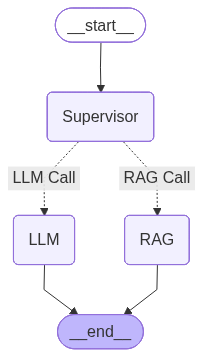

In [52]:
workflow.compile()